# Additional testing cases: vertical table



## Set autoreload, library importing, logging, and environment 

In [2]:
# Enable autoreload to automatically pick up changes in local modules
%load_ext autoreload
%autoreload 2

In [3]:
# Import libraries
import logging
from pathlib import Path
from IPython.display import display, Markdown, Image

from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.pipeline_options import PdfPipelineOptions
from docling.datamodel.base_models import InputFormat

from doc_agent.utils.logger import setup_logger
from doc_agent.ingestion.docling_parser import parse_document
from utils.extract_page import extract_page_image
from utils.encode_image import encode_image_to_base64


# Configure logging
# Local notebook logger
logger = setup_logger(
    name="004_additional_testing_cases_1", 
    level=logging.INFO,
    log_file="notebook_experiments.log",
    log_dir=Path.cwd() / "logs"
)

logger.info("Logging system successfully initialized.")

2026-05-06 21:47:46 |     INFO | 004_additional_testing_cases_1:2889204085.py:25 - Logging system successfully initialized.


## Workspace & Path Configuration
Setting up relative paths for raw documents, interim data (extracted images and Markdown), and processed outputs.

In [4]:
# Paths relative to the notebook's location (notebooks/data/...)
notebook_root = Path.cwd()
# Path to the pdf-file
pdf_file = notebook_root / "data" / "01_raw" / "one_page_vertical_table.pdf"
logger.info(f"Path to the pdf-file: {pdf_file}")
# Path to the raw md-file
raw_markdown_file = notebook_root / "data" / "02_interim" / "one_page_vertical_table.md"
logger.info(f"Path to the md-file: {raw_markdown_file}")
# Path to the extracted page images
page_images_dir = notebook_root / "data" / "02_interim" / "page_images" 
logger.info(f"Path to the page images directory: {page_images_dir}")

docling_images_dir = notebook_root / "data" / "02_interim" / "docling_images"
logger.info(f"Path to the docling images directory: {docling_images_dir}")


2026-05-06 21:47:47 |     INFO | 004_additional_testing_cases_1:675186827.py:5 - Path to the pdf-file: /Volumes/SSD/AI/doc_agent/notebooks/data/01_raw/one_page_vertical_table.pdf
2026-05-06 21:47:47 |     INFO | 004_additional_testing_cases_1:675186827.py:8 - Path to the md-file: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/one_page_vertical_table.md
2026-05-06 21:47:47 |     INFO | 004_additional_testing_cases_1:675186827.py:11 - Path to the page images directory: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/page_images
2026-05-06 21:47:47 |     INFO | 004_additional_testing_cases_1:675186827.py:14 - Path to the docling images directory: /Volumes/SSD/AI/doc_agent/notebooks/data/02_interim/docling_images


In [5]:
logger.info("Starting document parsing process to extract AST...")

# 1. Configure parser options 
pipeline_options = PdfPipelineOptions()
pipeline_options.do_formula_enrichment = True
pipeline_options.generate_picture_images = True
pipeline_options.do_ocr = False # Disable aggressive OCR for schematics

converter = DocumentConverter(
    format_options={
        InputFormat.PDF: PdfFormatOption(pipeline_options=pipeline_options)
    }
)

# 2. Parse the document and retrieve the raw AST (graph)
result = converter.convert(pdf_file)
doc = result.document

logger.info("AST extraction completed")

# 3. Export the raw md-file
raw_markdown_content = doc.export_to_markdown()
raw_markdown_file.write_text(raw_markdown_content, encoding="utf-8")
logger.info(f"Raw markdown successfully saved to {raw_markdown_file.name}")

2026-05-06 21:47:47 |     INFO | 004_additional_testing_cases_1:1272657087.py:1 - Starting document parsing process to extract AST...
2026-05-06 21:48:17 |     INFO | 004_additional_testing_cases_1:1272657087.py:19 - AST extraction completed
2026-05-06 21:48:17 |     INFO | 004_additional_testing_cases_1:1272657087.py:24 - Raw markdown successfully saved to one_page_vertical_table.md


## Create JSON dump from docling structure

In [6]:
import json

with open(notebook_root / "data" / "02_interim" / "ast_dump.json", "w", encoding="utf-8") as f:
    json.dump(doc.export_to_dict(), f, indent=2, ensure_ascii=False)
    
logger.info("JSON dump created.")

2026-05-06 21:48:17 |     INFO | 004_additional_testing_cases_1:3465166242.py:6 - JSON dump created.


## Semantic XML Tagging Execution
Now we apply the `generate_tagged_markdown` function to our parsed `docling` object. 
This step iterates through the document's AST and wraps each semantic block in unique XML-like tags (e.g., `<text_1>...</text_1>`). As a result, we obtain a rigid markup ("factura") that creates ironclad attention boundaries, preventing the VLM from losing context or shuffling paragraphs during the healing phase.

In [7]:
from utils.genetate_tagged_markdown import generate_tagged_markdown

logger.info("Executing XML tagging process...")

# Define the output path for the tagged Markdown file
tagged_md_file = notebook_root / "data" / "02_interim" / f"{pdf_file.stem}_tagged.md"

# Generate the tagged content and persist it to disk
tagged_content = generate_tagged_markdown(
    doc=doc, 
    output_path=tagged_md_file
)

logger.info(f"Tagged markdown successfully generated and saved to {tagged_md_file.name}")
logger.info(f"Total length of tagged content: {len(tagged_content)} characters")

# Render a preview of the resulting tagged text (first 1000 characters)
logger.info("Rendering preview of the tagged markdown:")
print(tagged_content[:1000] + "\n\n... (text truncated for preview)")

2026-05-06 21:48:18 |     INFO | 004_additional_testing_cases_1:446513549.py:3 - Executing XML tagging process...


Usage of TableItem.export_to_dataframe() without `doc` argument is deprecated.


2026-05-06 21:48:18 |     INFO | 004_additional_testing_cases_1:446513549.py:14 - Tagged markdown successfully generated and saved to one_page_vertical_table_tagged.md
2026-05-06 21:48:18 |     INFO | 004_additional_testing_cases_1:446513549.py:15 - Total length of tagged content: 6238 characters
2026-05-06 21:48:18 |     INFO | 004_additional_testing_cases_1:446513549.py:18 - Rendering preview of the tagged markdown:
<text_1>
ствовать требованиям настоящих Правил и про -ектным данным .
</text_1>

<section_header_1>
2. Проверка цепи между заземлителями и за -земляемыми элементами .
</section_header_1>

<text_2>
Следует проверить сечения , целостность и прочность проводников , их соединений и присо -единений . Не должно быть обрывов и видимых дефектов в заземляющих проводниках , соеди -няющих аппараты с заземлителем . Надежность сварки проверяется ударом молотка .
</text_2>

<section_header_2>
3. Проверка состояния пробивных предохра -нителей в электроустановках до 1 кВ .
</section_head

## Extract the target page as a PNG image using PyPDFium2

2026-05-06 21:48:18 |     INFO | 004_additional_testing_cases_1:677466353.py:1 - Starting image extraction  from one_page_vertical_table.pdf...
2026-05-06 21:48:18 |     INFO | 004_additional_testing_cases_1:677466353.py:9 - Image extraction complete. Rendering preview...


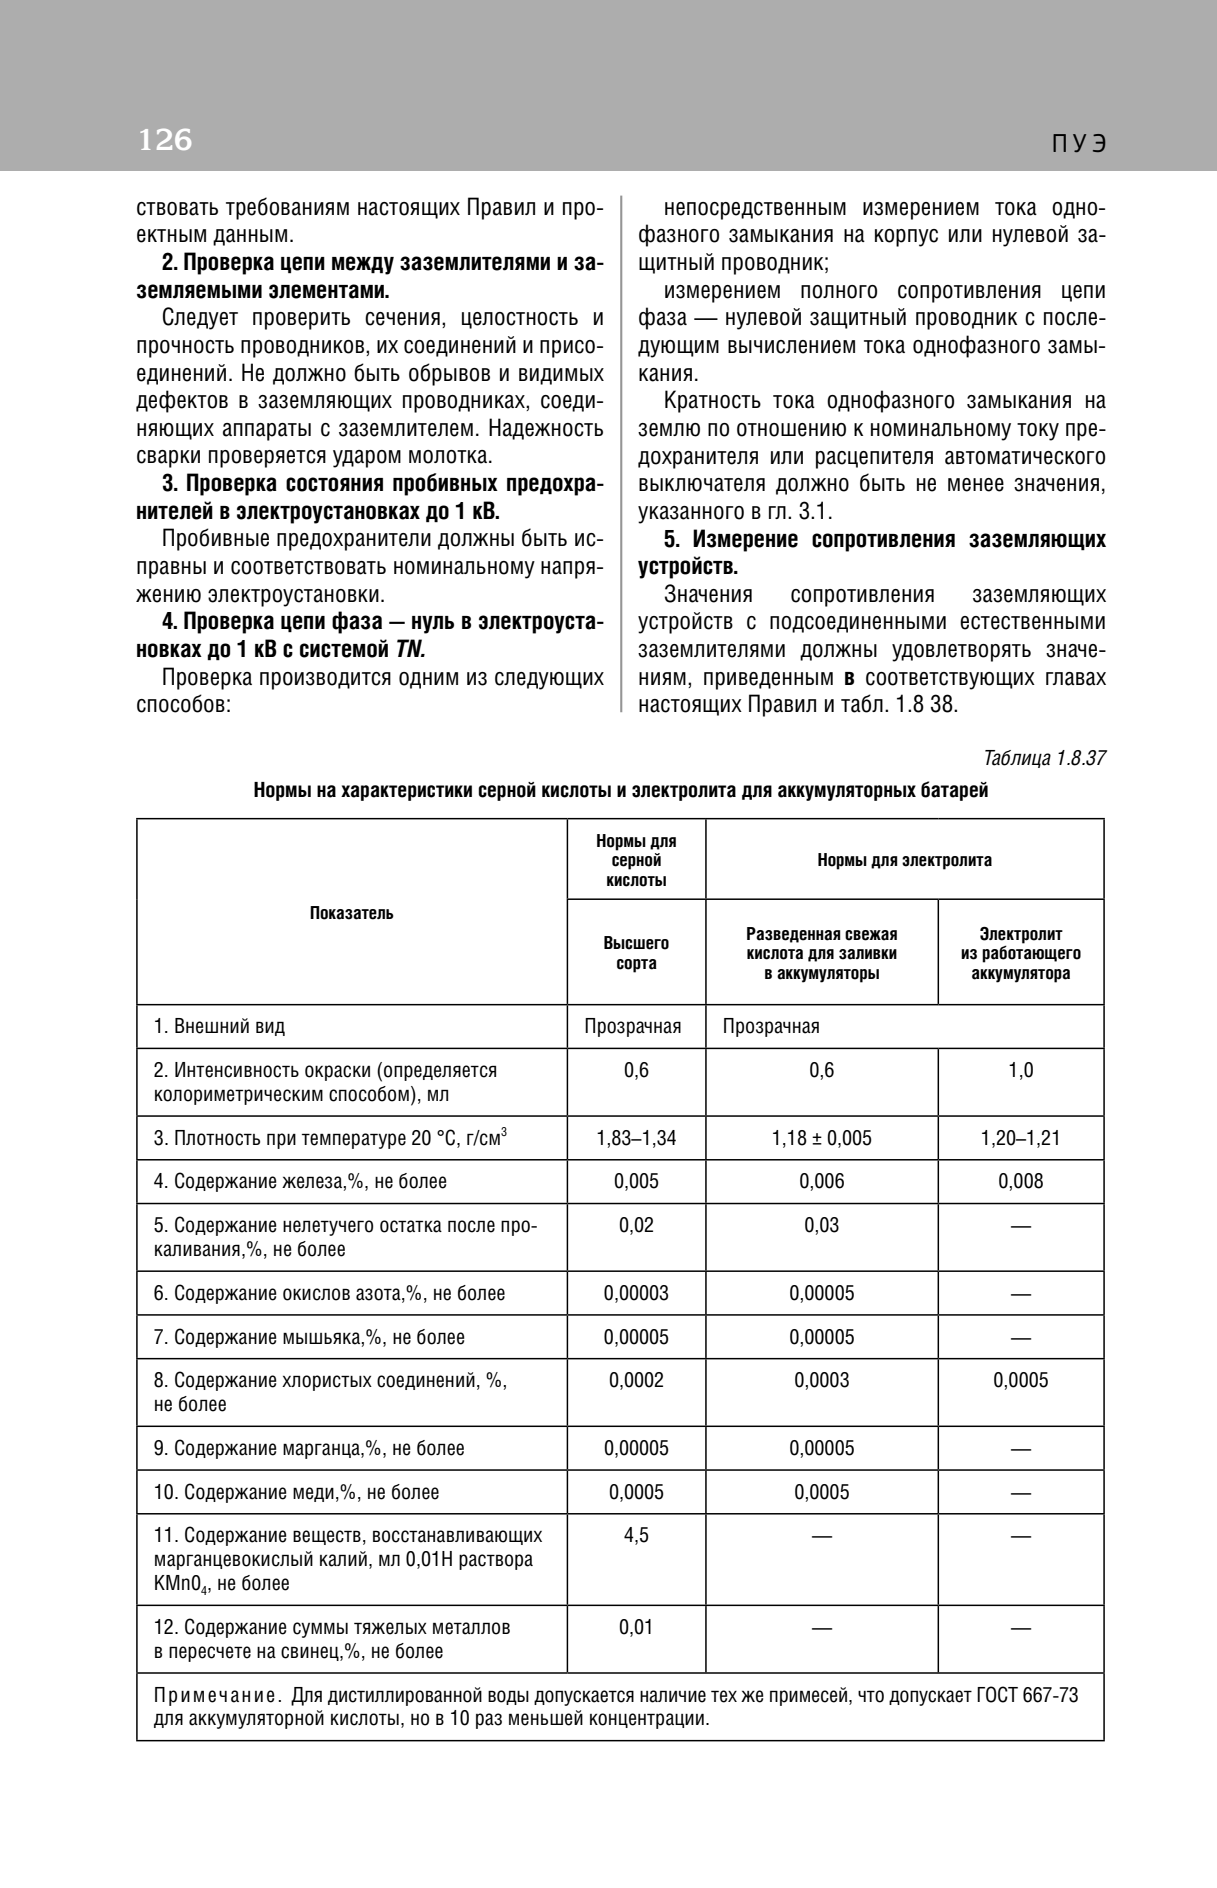

In [8]:
logger.info(f"Starting image extraction  from {pdf_file.name}...")

# Extract the target page as a PNG image
target_image = extract_page_image(
    pdf_path=pdf_file, 
    output_dir=page_images_dir
)

logger.info("Image extraction complete. Rendering preview...")

# Display the extracted image inline
display(Image(filename=target_image, width=800))

## Preparing Inputs for the Vision-Language Model (VLM)
Loading the saved Markdown into memory and converting the target image into a base64 string required by the OpenAI API spec.

In [9]:
# Load raw text
raw_markdown = raw_markdown_file.read_text(encoding="utf-8")
logger.info(f"Loaded raw Markdown: {len(raw_markdown)} characters.")

# Convert image to Base64
base64_image = encode_image_to_base64(target_image)
logger.info("Page image successfully encoded to Base64.")

2026-05-06 21:48:18 |     INFO | 004_additional_testing_cases_1:2864798789.py:3 - Loaded raw Markdown: 5207 characters.
2026-05-06 21:48:18 |     INFO | 004_additional_testing_cases_1:2864798789.py:7 - Page image successfully encoded to Base64.


## Agent Inference with Tagged Source Data
Now that we have the tagged text (Tagged MD), we send it to the VLM. We use a Native CoT approach (without rigid JSON-CoT) because the tags already provide the model with an excellent structure for maintaining focus.

In [10]:
import os
from openai import OpenAI
from pydantic import BaseModel, Field
from typing import List

# Setup API Client (assuming dotenv is loaded at the top of notebook)
client = OpenAI(
    api_key=os.environ.get("NANOGPT_API_KEY"),
    base_url=os.environ.get("NANOGPT_BASE_URL") 
)

TARGET_MODEL = "openai/gpt-5-mini" # The main model
# TARGET_MODEL = "google/gemini-flash-latest"
# TARGET_MODEL = "google/gemini-flash-lite-latest"
# TARGET_MODEL = "openai/gpt-5.4-nano"
# TARGET_MODEL = "Qwen/Qwen3.6-35B-A3B"
# TARGET_MODEL = "moonshotai/kimi-k2.6:thinking"
# TARGET_MODEL = "gemini-2.5-flash-preview-09-2025"
# TARGET_MODEL = "openai/gpt-5.4-mini"
# Use Native CoT prompt
prompt_file_cot = notebook_root / "prompts" / "semantic_normalization_native_cot_tagged.md"
system_prompt_cot = prompt_file_cot.read_text(encoding="utf-8")

class NormalizationResultLight(BaseModel):
    clean_markdown: str = Field(
        description="Final, structurally corrected Markdown text WITHOUT any XML tags."
    )

logger.info("Pydantic schema and prompts updated for Tagged processing.")

2026-05-06 21:48:18 |     INFO | 004_additional_testing_cases_1:1243371500.py:29 - Pydantic schema and prompts updated for Tagged processing.


In [11]:
from utils.encode_image import encode_image_to_base64
from utils.display_diff import display_diff

# Encode image
target_image = page_images_dir / f"{pdf_file.stem}_highres.png"
base64_image = encode_image_to_base64(target_image)

logger.info(f"Initiating inference with Tagged MD using model: {TARGET_MODEL}")

try:
    messages = [
        {"role": "system", "content": system_prompt_cot},
        {
            "role": "user",
            "content": [
                {
                    "type": "text", 
                    "text": f"Raw Tagged Markdown for processing:\n\n{tagged_content}"
                },
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{base64_image}",
                        "detail": "high"
                    }
                }
            ]
        }
    ]

    response = client.chat.completions.parse(
        model=TARGET_MODEL,
        messages=messages,
        temperature=0.0,
        response_format=NormalizationResultLight,
    )

    tagged_normalized_data = response.choices[0].message.parsed
    logger.info("Inference complete. Checking output...")
    
    # Save the result
    processed_dir = notebook_root / "data" / "03_processed"
    final_output_file = processed_dir / f"{pdf_file.stem}_clean_tagged.md"
    final_output_file.write_text(tagged_normalized_data.clean_markdown, encoding="utf-8")
    
    logger.info(f"Saved to: {final_output_file.name}")

    # Visual Diff: Compare the raw md-file (no tags) and the cleaned md-file
    raw_untagged_md = raw_markdown_file.read_text(encoding="utf-8")
    
    display_diff(
        text_before=raw_untagged_md, 
        text_after=tagged_normalized_data.clean_markdown,
        fromfile='Raw_Docling_Untagged',
        tofile='LLM_Healed_via_Tags'
    )

except Exception as e:
    logger.error(f"Inference failed. Error: {e}", exc_info=True)

2026-05-06 21:48:18 |     INFO | 004_additional_testing_cases_1:3722612486.py:8 - Initiating inference with Tagged MD using model: openai/gpt-5-mini
2026-05-06 21:49:11 |     INFO | 004_additional_testing_cases_1:3722612486.py:39 - Inference complete. Checking output...
2026-05-06 21:49:11 |     INFO | 004_additional_testing_cases_1:3722612486.py:46 - Saved to: one_page_vertical_table_clean_tagged.md


```diff
--- Raw_Docling_Untagged
+++ LLM_Healed_via_Tags
@@ -1,45 +1,43 @@
-ствовать требованиям настоящих Правил и про -ектным данным .
+соответствовать требованиям настоящих Правил и проектным данным.
 
-## 2. Проверка цепи между заземлителями и за -земляемыми элементами .
+#### 2. Проверка цепи между заземлителями и заземляемыми элементами.
 
-Следует проверить сечения , целостность и прочность проводников , их соединений и присо -единений . Не должно быть обрывов и видимых дефектов в заземляющих проводниках , соеди -няющих аппараты с заземлителем . Надежность сварки проверяется ударом молотка .
+Следует проверить сечения, целостность и прочность проводников, их соединений и присоединений. Не должно быть обрывов и видимых дефектов в заземляющих проводниках, соединяющих аппараты с заземлителем. Надежность сварки проверяется ударом молотка.
 
-## 3. Проверка состояния пробивных предохра -нителей в электроустановках до 1 кВ .
+#### 3. Проверка состояния пробивных предохранителей в электроустановках до 1 кВ.
 
-Пробивные предохранители должны быть ис -правны и соответствовать номинальному напря -жению электроустановки .
+Пробивные предохранители должны быть исправны и соответствовать номинальному напряжению электроустановки.
 
-## 4. Проверка цепи фаза -нуль в электроуста -новках до 1 кВ с системой TN.
+#### 4. Проверка цепи фаза-нуль в электроустановках до 1 кВ с системой TN.
 
-Проверка производится одним из следующих способов :
+Проверка производится одним из следующих способов:
 
-непосредственным измерением тока одно -фазного замыкания на корпус или нулевой за -щитный проводник ;
+- непосредственным измерением тока однофазного замыкания на корпус или нулевой защитный проводник;
+- измерением полного сопротивления цепи фаза — нулевой защитный проводник с последующим вычислением тока однофазного замыкания.
 
-измерением полного сопротивления цепи фаза -нулевой защитный проводник с после -дующим вычислением тока однофазного замы -кания .
+Кратность тока однофазного замыкания на землю по отношению к номинальному току предохранителя или расцепителя автоматического выключателя должно быть не менее значения, указанного в гл. 3.1.
 
-Кратность тока однофазного замыкания на землю по отношению к номинальному току пре -дохранителя или расцепителя автоматического выключателя должно быть не менее значения , указанного в гл . 3.1.
+#### 5. Измерение сопротивления заземляющих устройств.
 
-## 5. Измерение сопротивления заземляющих устройств .
-
-Значения сопротивления заземляющих устройств с подсоединенными естественными заземлителями должны удовлетворять значе -ниям , приведенным в соответствующих главах настоящих Правил и табл . 1.8 38.
+Значения сопротивления заземляющих устройств с подсоединенными естественными заземлителями должны удовлетворять значениям, приведенным в соответствующих главах настоящих Правил и табл. 1.8.38.
 
 Таблица 1.8.37
 
-## Нормы на характеристики серной кислоты и электролита для аккумуляторных батарей
+### Нормы на характеристики серной кислоты и электролита для аккумуляторных батарей
 
-| Показатель                                                                                                | Нормы для серной кислоты   | Нормы для электролита                                 | Нормы для электролита                  |
-|-----------------------------------------------------------------------------------------------------------|----------------------------|-------------------------------------------------------|----------------------------------------|
-|                                                                                                           | Высшего сорта              | Разведенная свежая кислота для заливки в аккумуляторы | Электролит из работающего аккумулятора |
-| 1. Внешний вид                                                                                            | Прозрачная                 | Прозрачная                                            | Прозрачная                             |
-| 2. Интенсивность окраски ( определяется колориметрическим способом ), мл                                  | 0,6                        | 0,6                                                   | 1,0                                    |
-| 3. Плотность при температуре 20 ° С , г / см 3                                                            | 1,83-1,34                  | 1,18 ± 0,005                                          | 1,20-1,21                              |
-| 4. Содержание железа ,%, не более                                                                         | 0,005                      | 0,006                                                 | 0,008                                  |
-| 5. Содержание нелетучего остатка после про - каливания ,%, не более                                       | 0,02                       | 0,03                                                  | -                                      |
-| 6. Содержание окислов азота ,%, не более                                                                  | 0,00003                    | 0,00005                                               | -                                      |
-| 7. Содержание мышьяка ,%, не более                                                                        | 0,00005                    | 0,00005                                               | -                                      |
-| 8. Содержание хлористых соединений , %, не более                                                          | 0,0002                     | 0,0003                                                | 0,0005                                 |
-| 9. Содержание марганца ,%, не более                                                                       | 0,00005                    | 0,00005                                               | -                                      |
-| 10. Содержание меди ,%, не более                                                                          | 0,0005                     | 0,0005                                                | -                                      |
-| 11. Содержание веществ , восстанавливающих марганцевокислый калий , мл 0,01 Н раствора КМ n0 4 , не более | 4,5                        | -                                                     | -                                      |
-| 12. Содержание суммы тяжелых металлов в пересчете на свинец ,%, не более                                  | 0,01                       | -                                                     | -                                      |
+| Показатель                                                                 | Нормы для серной кислоты (высшего сорта) | Нормы для электролита: разведенная свежая кислота для заливки в аккумуляторы | Нормы для электролита: электролит из работающего аккумулятора |
+|:---------------------------------------------------------------------------|:-----------------------------------------:|:----------------------------------------------------------------------------:|:----------------------------------------------------------------:|
+| 1. Внешний вид                                                              | Прозрачная                                | Прозрачная                                                                   | Прозрачная                                                       |
+| 2. Интенсивность окраски (определяется колориметрическим способом), мл      | 0,6                                       | 0,6                                                                          | 1,0                                                              |
+| 3. Плотность при температуре 20 °C, г/см3                                   | 1,83-1,34                                 | 1,18 ± 0,005                                                                 | 1,20–1,21                                                        |
+| 4. Содержание железа, %, не более                                          | 0,005                                     | 0,006                                                                        | 0,008                                                            |
+| 5. Содержание нелетучего остатка после прокаливания, %, не более            | 0,02                                      | 0,03                                                                         | -                                                                 |
+| 6. Содержание окислов азота, %, не более                                   | 0,00003                                   | 0,00005                                                                      | -                                                                 |
+| 7. Содержание мышьяка, %, не более                                         | 0,00005                                   | 0,00005                                                                      | -                                                                 |
+| 8. Содержание хлористых соединений, %, не более                            | 0,0002                                    | 0,0003                                                                       | 0,0005                                                           |
+| 9. Содержание марганца, %, не более                                        | 0,00005                                   | 0,00005                                                                      | -                                                                 |
+| 10. Содержание меди, %, не более                                           | 0,0005                                    | 0,0005                                                                       | -                                                                 |
+| 11. Содержание веществ, восстанавливающих марганцевокислый калий, мл 0,01 Н раствора KMnO4, не более | 4,5                                       | -                                                                            | -                                                                 |
+| 12. Содержание суммы тяжелых металлов в пересчете на свинец, %, не более   | 0,01                                      | -                                                                            | -                                                                 |
 
-Примечание . Для дистиллированной воды допускается наличие тех же примесей , что допускает ГОСТ 667-73 для аккумуляторной кислоты , но в 10 раз меньшей концентрации .
+Примечание. Для дистиллированной воды допускается наличие тех же примесей, что допускает ГОСТ 667-73 для аккумуляторной кислоты, но в 10 раз меньшей концентрации.
```

## Output

The final output is correct.

<div style="border: 2px solid #388e3c; border-radius: 8px; padding: 20px; background-color: rgba(56, 142, 60, 0.05); box-shadow: 0 4px 6px rgba(0,0,0,0.05); width: fit-content;">

<h3 style="margin-top: 0; color: #388e3c; border-bottom: 1px solid #388e3c; padding-bottom: 8px;">
  📄 Output
</h3>

соответствовать требованиям настоящих Правил и проектным данным.

#### 2. Проверка цепи между заземлителями и заземляемыми элементами.

Следует проверить сечения, целостность и прочность проводников, их соединений и присоединений. Не должно быть обрывов и видимых дефектов в заземляющих проводниках, соединяющих аппараты с заземлителем. Надежность сварки проверяется ударом молотка.

#### 3. Проверка состояния пробивных предохранителей в электроустановках до 1 кВ.

Пробивные предохранители должны быть исправны и соответствовать номинальному напряжению электроустановки.

#### 4. Проверка цепи фаза — нуль в электроустановках до 1 кВ с системой TN.

Проверка производится одним из следующих способов:

- непосредственным измерением тока однофазного замыкания на корпус или нулевой защитный проводник;
- измерением полного сопротивления цепи фаза — нулевой защитный проводник с последующим вычислением тока однофазного замыкания.

Кратность тока однофазного замыкания на землю по отношению к номинальному току предохранителя или расцепителя автоматического выключателя должно быть не менее значения, указанного в гл. 3.1.

#### 5. Измерение сопротивления заземляющих устройств.

Значения сопротивления заземляющих устройств с подсоединенными естественными заземлителями должны удовлетворять значениям, приведенным в соответствующих главах настоящих Правил и в табл. 1.8.37.

### Таблица 1.8.37. Нормы на характеристики серной кислоты и электролита для аккумуляторных батарей

| Показатель | Нормы для серной кислоты (высшего сорта) | Нормы для электролита — разведенная свежая кислота для заливки в аккумуляторы | Нормы для электролита — электролит из работающего аккумулятора |
|:---|:---:|:---:|:---:|
| 1. Внешний вид | Прозрачная | Прозрачная | Прозрачная |
| 2. Интенсивность окраски (определяется колориметрическим способом), мл | 0,6 | 0,6 | 1,0 |
| 3. Плотность при температуре 20 °C, г/см³ | 1,83-1,34 | 1,18 ± 0,005 | 1,20–1,21 |
| 4. Содержание железа, %, не более | 0,005 | 0,006 | 0,008 |
| 5. Содержание нелетучего остатка после прокаливания, %, не более | 0,02 | 0,03 | — |
| 6. Содержание окислов азота, %, не более | 0,00003 | 0,00005 | — |
| 7. Содержание мышьяка, %, не более | 0,00005 | 0,00005 | — |
| 8. Содержание хлористых соединений, %, не более | 0,0002 | 0,0003 | 0,0005 |
| 9. Содержание марганца, %, не более | 0,00005 | 0,00005 | — |
| 10. Содержание меди, %, не более | 0,0005 | 0,0005 | — |
| 11. Содержание веществ, восстанавливающих марганцевокислый калий, мл 0,01 Н раствора KMnO₄, не более | 4,5 | — | — |
| 12. Содержание суммы тяжелых металлов в пересчете на свинец, %, не более | 0,01 | — | — |

Примечание. Для дистиллированной воды допускается наличие тех же примесей, что допускает ГОСТ 667-73 для аккумуляторной кислоты, но в 10 раз меньшей концентрации.




</div>